In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/synthetic_fraud_dataset.csv")

print("Shape", df.shape)
df.head(10)

Shape (50000, 21)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1
5,TXN_42724,USER_6852,168.55,Online,2023-06-05 20:55:00,33236.94,Laptop,Tokyo,Restaurants,0,...,3,226.85,2,Discover,51,1725.64,OTP,0.0504,0,0
6,TXN_10822,USER_5052,3.79,POS,2023-11-07 01:18:00,86834.18,Tablet,London,Restaurants,0,...,2,298.35,2,Mastercard,168,3757.19,Password,0.0875,0,0
7,TXN_49498,USER_4660,7.08,ATM Withdrawal,2023-02-25 03:43:00,45826.27,Tablet,London,Restaurants,0,...,3,164.38,4,Discover,182,1764.66,Biometric,0.5326,0,1
8,TXN_4144,USER_1584,34.25,ATM Withdrawal,2023-03-09 22:51:00,94392.35,Tablet,Tokyo,Clothing,0,...,7,90.02,3,Visa,24,550.38,Biometric,0.1347,1,0
9,TXN_36958,USER_9498,16.24,POS,2023-09-20 17:27:00,91859.97,Mobile,Mumbai,Travel,0,...,6,474.42,1,Mastercard,124,720.91,PIN,0.3394,0,0


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,50000,50000,TXN_5311,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_ID,50000,8963,USER_6599,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction_Amount,50000.0,NaN,NaN,NaN,99.411012,98.687292,0.0,28.6775,69.66,138.8525,1174.14
Transaction_Type,50000,4,POS,12549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,50000,47724,2023-06-04 06:35:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account_Balance,50000.0,NaN,NaN,NaN,50294.065981,28760.458557,500.48,25355.995,50384.43,75115.135,99998.31
Device_Type,50000,3,Tablet,16779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,50000,5,Tokyo,10208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Merchant_Category,50000,5,Clothing,10033,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IP_Address_Flag,50000.0,NaN,NaN,NaN,0.0502,0.21836,0.0,0.0,0.0,0.0,1.0


In [4]:
print(df.columns.tolist())

['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Timestamp', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age', 'Transaction_Distance', 'Authentication_Method', 'Risk_Score', 'Is_Weekend', 'Fraud_Label']


In [5]:
TARGET = "Fraud_Label"

X = df.drop(columns=[TARGET])
y = df[TARGET]

In [6]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True) * 100)

Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64


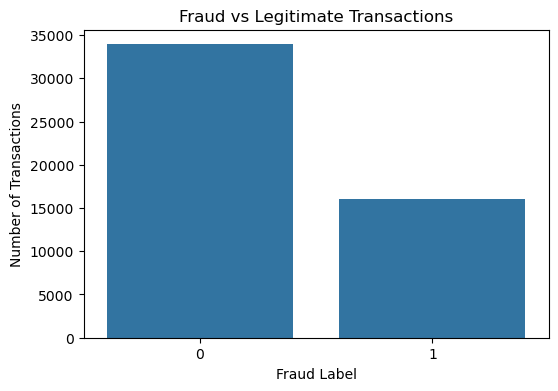

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud Label")
plt.ylabel("Number of Transactions")
plt.show()

In [8]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Series([], dtype: int64)


In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Transaction IDs:", df["Transaction_ID"].duplicated().sum())
print("Unique users:", df["User_ID"].nunique())

Duplicate rows: 0
Duplicate Transaction IDs: 0
Unique users: 8963


In [11]:
pd.crosstab(
    df["Transaction_Type"],
    df["Fraud_Label"],
    normalize="index"
).mul(100).round(2)

Fraud_Label,0,1
Transaction_Type,,
ATM Withdrawal,67.51,32.49
Bank Transfer,67.92,32.08
Online,67.87,32.13
POS,68.16,31.84


In [12]:
pd.crosstab(
    df["Device_Type"],
    df["Fraud_Label"],
    normalize="index"
).mul(100).round(2)

Fraud_Label,0,1
Device_Type,,
Laptop,68.05,31.95
Mobile,68.12,31.88
Tablet,67.44,32.56


In [13]:
pd.crosstab(
    df["Merchant_Category"],
    df["Fraud_Label"],
    normalize="index"
).mul(100).round(2)

Fraud_Label,0,1
Merchant_Category,,
Clothing,68.29,31.71
Electronics,68.07,31.93
Groceries,67.89,32.11
Restaurants,67.37,32.63
Travel,67.70,32.30


In [14]:
pd.crosstab(
    df["Authentication_Method"],
    df["Fraud_Label"],
    normalize="index"
).mul(100).round(2)

Fraud_Label,0,1
Authentication_Method,,
Biometric,67.93,32.07
OTP,67.48,32.52
PIN,68.39,31.61
Password,67.65,32.35


In [15]:
numeric_cols = [
    "Transaction_Amount",
    "Account_Balance",
    "Daily_Transaction_Count",
    "Avg_Transaction_Amount_7d",
    "Failed_Transaction_Count_7d",
    "Card_Age",
    "Transaction_Distance",
    "Risk_Score"
]

df.groupby("Fraud_Label")[numeric_cols].mean().T

Fraud_Label,0,1
Transaction_Amount,99.281907,99.683678
Account_Balance,50356.472852,50162.264626
Daily_Transaction_Count,7.504877,7.443767
Avg_Transaction_Amount_7d,255.203530,255.416370
Failed_Transaction_Count_7d,1.507353,3.051472
Card_Age,120.148056,119.687123
Transaction_Distance,2499.278762,2498.922109
Risk_Score,0.425158,0.662904


In [16]:
df.groupby("Fraud_Label")[numeric_cols].median().T

Fraud_Label,0,1
Transaction_Amount,69.4000,70.1200
Account_Balance,50370.3500,50415.0200
Daily_Transaction_Count,7.0000,7.0000
Avg_Transaction_Amount_7d,256.0500,256.2100
Failed_Transaction_Count_7d,2.0000,4.0000
Card_Age,120.0000,119.0000
Transaction_Distance,2487.6800,2496.6600
Risk_Score,0.4263,0.8069


In [17]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [18]:
df["transaction_hour"] = df["Timestamp"].dt.hour
df["transaction_day"] = df["Timestamp"].dt.day
df["transaction_month"] = df["Timestamp"].dt.month
df["transaction_dayofweek"] = df["Timestamp"].dt.dayofweek

In [19]:
df["amount_vs_avg_7d"] = (
    df["Transaction_Amount"] /
    (df["Avg_Transaction_Amount_7d"] + 1e-6)
)

In [20]:
df["failed_transaction_ratio"] = (
    df["Failed_Transaction_Count_7d"] /
    (df["Daily_Transaction_Count"] + 1)
)

In [21]:
df["amount_balance_ratio"] = (
    df["Transaction_Amount"] /
    (df["Account_Balance"] + 1e-6)
)

In [22]:
new_features = [
    "amount_vs_avg_7d",
    "failed_transaction_ratio",
    "amount_balance_ratio"
]

df[new_features].describe()

,amount_vs_avg_7d,failed_transaction_ratio,amount_balance_ratio
count,50000.000000,50000.000000,50000.000000
mean,0.798661,0.333620,0.005300
std,1.864890,0.376218,0.019568
min,0.000000,0.000000,0.000000
25%,0.117795,0.083333,0.000597
50%,0.307622,0.250000,0.001578
75%,0.732966,0.428571,0.003813
max,61.047111,2.000000,1.052142


In [23]:
print("Earliest:", df["Timestamp"].min())
print("Latest:", df["Timestamp"].max())

Earliest: 2023-01-01 00:01:00
Latest: 2023-12-31 23:50:00


In [24]:
print(df["Timestamp"].dt.to_period("M").value_counts().sort_index())

Timestamp
2023-01    4188
2023-02    3903
2023-03    4259
2023-04    4106
2023-05    4162
2023-06    4160
2023-07    4213
2023-08    4384
2023-09    4087
2023-10    4164
2023-11    4085
2023-12    4289
Freq: M, Name: count, dtype: int64


In [25]:
df = df.sort_values("Timestamp").reset_index(drop=True)

In [26]:
train_end = df["Timestamp"].quantile(0.70)
val_end = df["Timestamp"].quantile(0.85)

train_df = df[df["Timestamp"] < train_end].copy()

val_df = df[
    (df["Timestamp"] >= train_end) &
    (df["Timestamp"] < val_end)
].copy()

test_df = df[df["Timestamp"] >= val_end].copy()

In [27]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (35000, 28)
Validation: (7500, 28)
Test: (7500, 28)


In [28]:
print("TRAIN")
print(train_df["Timestamp"].min(), "→", train_df["Timestamp"].max())

print("\nVALIDATION")
print(val_df["Timestamp"].min(), "→", val_df["Timestamp"].max())

print("\nTEST")
print(test_df["Timestamp"].min(), "→", test_df["Timestamp"].max())

TRAIN
2023-01-01 00:01:00 → 2023-09-12 22:31:00

VALIDATION
2023-09-12 22:36:00 → 2023-11-07 09:53:00

TEST
2023-11-07 10:10:00 → 2023-12-31 23:50:00


In [29]:
print("Train fraud rate:")
print(train_df["Fraud_Label"].mean())

print("\nValidation fraud rate:")
print(val_df["Fraud_Label"].mean())

print("\nTest fraud rate:")
print(test_df["Fraud_Label"].mean())

Train fraud rate:
0.3219714285714286

Validation fraud rate:
0.3144

Test fraud rate:
0.3253333333333333


In [30]:
for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(
        f"{name}: "
        f"{data['Fraud_Label'].mean() * 100:.2f}% fraud "
        f"({data['Fraud_Label'].sum()} / {len(data)})"
    )

Train: 32.20% fraud (11269 / 35000)
Validation: 31.44% fraud (2358 / 7500)
Test: 32.53% fraud (2440 / 7500)


In [31]:
TARGET = "Fraud_Label"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

In [32]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (35000, 27)
y_train: (35000,)
X_val: (7500, 27)
y_val: (7500,)
X_test: (7500, 27)
y_test: (7500,)


In [33]:
# Convert timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort chronologically
df = df.sort_values("Timestamp").reset_index(drop=True)

# Temporal boundaries
train_end = df["Timestamp"].quantile(0.70)
val_end = df["Timestamp"].quantile(0.85)

# Split
train_df = df[df["Timestamp"] < train_end].copy()

val_df = df[
    (df["Timestamp"] >= train_end) &
    (df["Timestamp"] < val_end)
].copy()

test_df = df[df["Timestamp"] >= val_end].copy()

# Target
TARGET = "Fraud_Label"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

# Verify
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nFraud rates:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

print("\nDate ranges:")
print("Train:", train_df["Timestamp"].min(), "→", train_df["Timestamp"].max())
print("Val:", val_df["Timestamp"].min(), "→", val_df["Timestamp"].max())
print("Test:", test_df["Timestamp"].min(), "→", test_df["Timestamp"].max())

Train: (35000, 27)
Validation: (7500, 27)
Test: (7500, 27)

Fraud rates:
Train: 0.3219714285714286
Validation: 0.3144
Test: 0.3253333333333333

Date ranges:
Train: 2023-01-01 00:01:00 → 2023-09-12 22:31:00
Val: 2023-09-12 22:36:00 → 2023-11-07 09:53:00
Test: 2023-11-07 10:10:00 → 2023-12-31 23:50:00


In [34]:
print(X_train.columns.tolist())


['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Timestamp', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age', 'Transaction_Distance', 'Authentication_Method', 'Risk_Score', 'Is_Weekend', 'transaction_hour', 'transaction_day', 'transaction_month', 'transaction_dayofweek', 'amount_vs_avg_7d', 'failed_transaction_ratio', 'amount_balance_ratio']


In [35]:
drop_cols = [
    "Transaction_ID",
    "User_ID",
    "Timestamp"
]

X_train = train_df.drop(columns=["Fraud_Label"] + drop_cols)
X_val = val_df.drop(columns=["Fraud_Label"] + drop_cols)
X_test = test_df.drop(columns=["Fraud_Label"] + drop_cols)

In [36]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
Numerical: ['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score', 'Is_Weekend', 'transaction_hour', 'transaction_day', 'transaction_month', 'transaction_dayofweek', 'amount_vs_avg_7d', 'failed_transaction_ratio', 'amount_balance_ratio']


In [37]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                dtype="float32"
            ),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [38]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [39]:
print(X_train_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)

(35000, 43)
(7500, 43)
(7500, 43)


In [43]:
from xgboost import XGBClassifier

In [44]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [45]:
model.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [46]:
y_val_proba = model.predict_proba(X_val_processed)[:, 1]

print(y_val_proba[:10])

[2.0099421e-04 9.9980468e-01 9.9980253e-01 1.4544536e-04 2.9279583e-04
 2.6060577e-04 1.3326705e-04 1.6511629e-04 1.3068205e-04 9.9916446e-01]


In [47]:
y_val_pred = (y_val_proba >= 0.5).astype(int)

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1       :", f1_score(y_val, y_val_pred))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_proba))
print("PR-AUC   :", average_precision_score(y_val, y_val_proba))

Accuracy : 0.9993333333333333
Precision: 0.9991514637250742
Recall   : 0.9987277353689568
F1       : 0.9989395546129375
ROC-AUC  : 0.9999977731657566
PR-AUC   : 0.999995163463216


In [49]:
cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[5140    2]
 [   3 2355]]


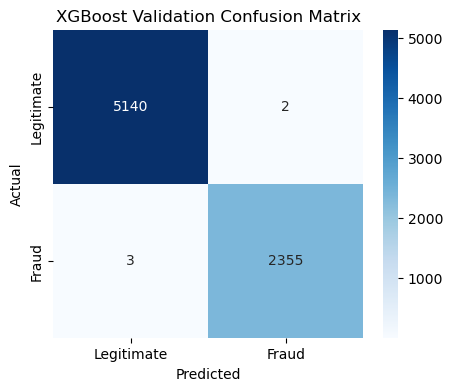

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Validation Confusion Matrix")

plt.show()

In [52]:
df.groupby("Fraud_Label")["Risk_Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Fraud_Label,,,,,,,,
0,33933.0,0.425158,0.243874,0.0001,0.2151,0.4263,0.6353,0.85
1,16067.0,0.662904,0.306187,0.0001,0.4051,0.8069,0.9197,1.00


In [53]:
df.groupby("Fraud_Label")[
    [
        "Transaction_Amount",
        "Risk_Score",
        "Previous_Fraudulent_Activity",
        "Failed_Transaction_Count_7d"
    ]
].mean()

,Transaction_Amount,Risk_Score,Previous_Fraudulent_Activity,Failed_Transaction_Count_7d
Fraud_Label,,,,
0,99.281907,0.425158,0.098547,1.507353
1,99.683678,0.662904,0.098089,3.051472


In [54]:
import pandas as pd

importance = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance.head(15))

                                         feature  importance
31        remainder__Failed_Transaction_Count_7d    0.596565
34                         remainder__Risk_Score    0.301655
41           remainder__failed_transaction_ratio    0.058087
29            remainder__Daily_Transaction_Count    0.018823
23        categorical__Authentication_Method_PIN    0.001582
15    categorical__Merchant_Category_Restaurants    0.001231
21  categorical__Authentication_Method_Biometric    0.001082
19             categorical__Card_Type_Mastercard    0.000949
25                 remainder__Transaction_Amount    0.000838
6                categorical__Device_Type_Tablet    0.000796
13    categorical__Merchant_Category_Electronics    0.000787
40                   remainder__amount_vs_avg_7d    0.000778
32                           remainder__Card_Age    0.000759
1    categorical__Transaction_Type_Bank Transfer    0.000758
30          remainder__Avg_Transaction_Amount_7d    0.000755


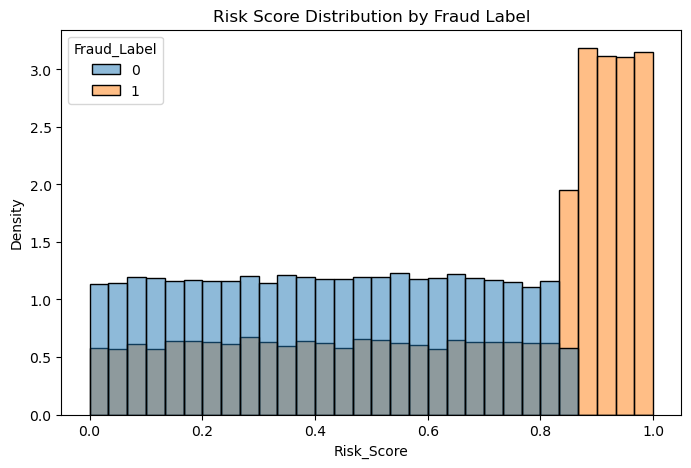

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Risk_Score",
    hue="Fraud_Label",
    bins=30,
    stat="density",
    common_norm=False
)

plt.title("Risk Score Distribution by Fraud Label")
plt.show()

In [56]:
corr = df.select_dtypes(
    include=["int64", "float64"]
).corr()["Fraud_Label"].sort_values(
    ascending=False
)

print(corr)

Fraud_Label                     1.000000
Failed_Transaction_Count_7d     0.509871
Risk_Score                      0.385810
failed_transaction_ratio        0.323391
IP_Address_Flag                 0.003028
amount_vs_avg_7d                0.002441
Transaction_Amount              0.001901
amount_balance_ratio            0.000998
Avg_Transaction_Amount_7d       0.000703
Is_Weekend                      0.000064
Transaction_Distance           -0.000116
Previous_Fraudulent_Activity   -0.000718
Card_Age                       -0.003120
Account_Balance                -0.003153
Daily_Transaction_Count        -0.007065
Name: Fraud_Label, dtype: float64


In [57]:
from sklearn.metrics import roc_auc_score

for feature in [
    "Failed_Transaction_Count_7d",
    "Risk_Score",
    "failed_transaction_ratio",
    "Daily_Transaction_Count"
]:
    auc = roc_auc_score(
        y_val,
        X_val[feature]
    )

    print(f"{feature}: {auc:.6f}")

Failed_Transaction_Count_7d: 0.808235
Risk_Score: 0.731918
failed_transaction_ratio: 0.713784
Daily_Transaction_Count: 0.498653


In [58]:
for feature in [
    "Failed_Transaction_Count_7d",
    "Risk_Score",
    "failed_transaction_ratio",
    "Daily_Transaction_Count"
]:
    print(
        feature,
        "\n",
        X_train.groupby(y_train)[feature].mean(),
        "\n"
    )

Failed_Transaction_Count_7d 
 Fraud_Label
0    1.507901
1    3.051735
Name: Failed_Transaction_Count_7d, dtype: float64 

Risk_Score 
 Fraud_Label
0    0.425939
1    0.665379
Name: Risk_Score, dtype: float64 

failed_transaction_ratio 
 Fraud_Label
0    0.250549
1    0.510786
Name: failed_transaction_ratio, dtype: float64 

Daily_Transaction_Count 
 Fraud_Label
0    7.500147
1    7.449641
Name: Daily_Transaction_Count, dtype: float64 



In [59]:
suspicious_features = [
    "Failed_Transaction_Count_7d",
    "Risk_Score",
    "failed_transaction_ratio"
]

In [60]:
X_train_no_suspicious = X_train.drop(
    columns=suspicious_features
)

X_val_no_suspicious = X_val.drop(
    columns=suspicious_features
)

X_test_no_suspicious = X_test.drop(
    columns=suspicious_features
)

In [61]:
categorical_cols_2 = X_train_no_suspicious.select_dtypes(
    include=["object", "category"]
).columns.tolist()

preprocessor_2 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                dtype="float32"
            ),
            categorical_cols_2
        )
    ],
    remainder="passthrough"
)

In [62]:
X_train_no_suspicious_processed = (
    preprocessor_2.fit_transform(X_train_no_suspicious)
)

X_val_no_suspicious_processed = (
    preprocessor_2.transform(X_val_no_suspicious)
)

In [63]:
model_no_suspicious = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model_no_suspicious.fit(
    X_train_no_suspicious_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [64]:
y_val_proba_2 = model_no_suspicious.predict_proba(
    X_val_no_suspicious_processed
)[:, 1]

y_val_pred_2 = (y_val_proba_2 >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_val, y_val_pred_2))
print("Precision:", precision_score(y_val, y_val_pred_2))
print("Recall   :", recall_score(y_val, y_val_pred_2))
print("F1       :", f1_score(y_val, y_val_pred_2))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_proba_2))
print("PR-AUC   :", average_precision_score(y_val, y_val_proba_2))

Accuracy : 0.6846666666666666
Precision: 0.3793103448275862
Recall   : 0.004664970313825276
F1       : 0.009216589861751152
ROC-AUC  : 0.4954378352004101
PR-AUC   : 0.3148400875609794
